# Agentic RAG

In [1]:
from langchain_community.document_loaders import WebBaseLoader
from langchain_community.vectorstores import FAISS
from langchain_openai import ChatOpenAI
from langchain_groq import ChatGroq
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_huggingface import HuggingFaceEmbeddings
import os
from dotenv import load_dotenv
load_dotenv()


d:\2026-courses\agenticai\langraph\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
USER_AGENT environment variable not set, consider setting it to identify your requests.


True

In [2]:
os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")

In [3]:
urls = [
    "https://en.wikipedia.org/wiki/Brad_Pitt",
    "https://en.wikipedia.org/wiki/Tom_Cruise"
]

# Add User-Agent header to make the request look like a real browser
headers = {
    'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/91.0.4472.124 Safari/537.36'
}

docs = [WebBaseLoader(url, header_template=headers).load() for url in urls]
docs

[[Document(metadata={'source': 'https://en.wikipedia.org/wiki/Brad_Pitt', 'title': 'Brad Pitt - Wikipedia', 'language': 'en'}, page_content='\n\n\n\nBrad Pitt - Wikipedia\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\nJump to content\n\n\n\n\n\n\n\nMain menu\n\n\n\n\n\nMain menu\nmove to sidebar\nhide\n\n\n\n\t\tNavigation\n\t\n\n\nMain pageContentsCurrent eventsRandom articleAbout WikipediaContact us\n\n\n\n\n\n\t\tContribute\n\t\n\n\nHelpLearn to editCommunity portalRecent changesUpload fileSpecial pages\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\nSearch\n\n\n\n\n\n\n\n\n\n\n\nSearch\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\nAppearance\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\nDonate\n\nCreate account\n\nLog in\n\n\n\n\n\n\n\n\nPersonal tools\n\n\n\n\n\n\nDonate\n\n\nCreate account\n\n\nLog in\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\nContents\nmove to sidebar\nhide\n\n\n\n\n(Top)\n\n\n\n\n\n1\nEarly life\n\n\n\n\n\n\n\n\n2\nCareer\n\n\n\n\nToggle Career subsection\

In [4]:
embeddings = HuggingFaceEmbeddings(model_name="all-MiniLM-L6-v2")

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 1786.59it/s]


In [5]:
docs_list = [item for sublist in docs for item in sublist]

text_splitter = RecursiveCharacterTextSplitter(chunk_size=1000, chunk_overlap=100)

doc_splits = text_splitter.split_documents(docs_list)

# Add all these text to vectorDB
vectoretore = FAISS.from_documents(doc_splits, embeddings)
retriever=vectoretore.as_retriever()

In [6]:
retriever.invoke("Who is Brad Pitt?")

[Document(id='76317c4a-2bbb-4ca6-ba30-3eff32448883', metadata={'source': 'https://en.wikipedia.org/wiki/Brad_Pitt', 'title': 'Brad Pitt - Wikipedia', 'language': 'en'}, page_content='Brad Pitt - Wikipedia\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\nJump to content\n\n\n\n\n\n\n\nMain menu\n\n\n\n\n\nMain menu\nmove to sidebar\nhide\n\n\n\n\t\tNavigation\n\t\n\n\nMain pageContentsCurrent eventsRandom articleAbout WikipediaContact us\n\n\n\n\n\n\t\tContribute\n\t\n\n\nHelpLearn to editCommunity portalRecent changesUpload fileSpecial pages\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\nSearch\n\n\n\n\n\n\n\n\n\n\n\nSearch\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\nAppearance\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\nDonate\n\nCreate account\n\nLog in\n\n\n\n\n\n\n\n\nPersonal tools\n\n\n\n\n\n\nDonate\n\n\nCreate account\n\n\nLog in\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\nContents\nmove to sidebar\nhide\n\n\n\n\n(Top)\n\n\n\n\n\n1\nEarly life\n\n\n\n\n\n\n\n\n2\nCareer\

In [7]:
### Convert Retriever to tool
from langchain_core.tools import create_retriever_tool

retriver_tool = create_retriever_tool(
    retriever,
    "retriever_vector_db_actors",
    "Search and run information about actors"
)

In [8]:
retriver_tool

StructuredTool(name='retriever_vector_db_actors', description='Search and run information about actors', args_schema=<class 'langchain_core.tools.retriever.RetrieverInput'>, func=<function create_retriever_tool.<locals>.func at 0x00000271ADFFDD00>, coroutine=<function create_retriever_tool.<locals>.afunc at 0x00000271ADFFDEE0>)

## Separate vector Store about singers and not actors


In [9]:
singers=[
    "https://en.wikipedia.org/wiki/Bob_Marley",
    "https://en.wikipedia.org/wiki/Gipsy_Kings"
]

docs=[WebBaseLoader(url).load() for url in singers]
docs

[[Document(metadata={'source': 'https://en.wikipedia.org/wiki/Bob_Marley', 'title': 'Bob Marley - Wikipedia', 'language': 'en'}, page_content='\n\n\n\nBob Marley - Wikipedia\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\nJump to content\n\n\n\n\n\n\n\nMain menu\n\n\n\n\n\nMain menu\nmove to sidebar\nhide\n\n\n\n\t\tNavigation\n\t\n\n\nMain pageContentsCurrent eventsRandom articleAbout WikipediaContact us\n\n\n\n\n\n\t\tContribute\n\t\n\n\nHelpLearn to editCommunity portalRecent changesUpload fileSpecial pages\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\nSearch\n\n\n\n\n\n\n\n\n\n\n\nSearch\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\nAppearance\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\nDonate\n\nCreate account\n\nLog in\n\n\n\n\n\n\n\n\nPersonal tools\n\n\n\n\n\n\nDonate\n\n\nCreate account\n\n\nLog in\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\nContents\nmove to sidebar\nhide\n\n\n\n\n(Top)\n\n\n\n\n\n1\nEarly life\n\n\n\n\n\n\n\n\n2\nCareer\n\n\n\n\nToggle Career subsecti

In [10]:
docs_list = [item for sublist in docs for item in sublist]

text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=1000, chunk_overlap=100
)

doc_splits = text_splitter.split_documents(docs_list)

## Add alll these text to vectordb

vectorstoresingers=FAISS.from_documents(
    documents=doc_splits,
    embedding=embeddings
)


retrieversingers=vectorstoresingers.as_retriever()

In [11]:
from langchain_core.tools import create_retriever_tool

singer=create_retriever_tool(
    retrieversingers,
    "retriever_vector_singers_information",
    "Search and run information about singers"
)

In [12]:
tools = [retriver_tool, singer]

## Langgraph Workflow

In [13]:
from typing import Annotated, Sequence
from typing_extensions import TypedDict

from langchain_core.messages import BaseMessage
from langgraph.graph.message import add_messages

d:\2026-courses\agenticai\langraph\Lib\site-packages\langgraph\cache\base\__init__.py:8: LangChainPendingDeprecationWarning: The default value of `allowed_objects` will change in a future version. Pass an explicit value (e.g., allowed_objects='messages' or allowed_objects='core') to suppress this warning.
  from langgraph.checkpoint.serde.jsonplus import JsonPlusSerializer


In [14]:
class AgentState(TypedDict):
    # The add_messages function defines how an update should be processed
    # Default is to replace. add_messages says "append"
    messages: Annotated[Sequence[BaseMessage], add_messages]



In [15]:
from langchain_groq import ChatGroq

llm=ChatGroq(model="llama-3.1-8b-instant")


In [16]:
def agent(state):
    """
    Invokes the agent model to generate a response based on the current state. Given the question, it will decide to retrieve using 
    the retriever tool or not.
    Args:
        state (messages): the current state of the conversation
    Returns:
        dict: The updated state with the agent's response appended to messages
    """
    # Get the last message
    print("---CALL AGENT---")
    messages=state["messages"]
    model=ChatGroq(model="llama-3.1-8b-instant")
    model= model.bind_tools(tools)
    response=model.invoke(messages)
    # We return a list, because this will get added to the existing list
    return {"messages": [response]}

In [18]:
from typing import Annotated, Literal, Sequence
from typing_extensions import TypedDict

import langchainhub as hub

#from langchain import hub
from langchain_core.messages import BaseMessage, HumanMessage
from langchain_core.output_parsers import StrOutputParser
from langchain_core.prompts import PromptTemplate

from pydantic import BaseModel, Field

In [19]:
### Edges
def grade_documents(state)->Literal["generate", "rewrite"]:
    """
    Determines whether the retrieved documents are relevants to the question.
    Args:
        state (messages): the current staticmethod
    Returns:
        str: A decision for whether the docuemnts are relevant or not
    """

    print("---CHECK RELEVANCE---")

    # Data Model
    class grade(BaseModel):
        """Binary score for relevance check."""
        binary_score: str = Field(description="Relevance score 'yes' or 'no'")
    
    model=ChatGroq(model="llama-3.1-8b-instant")
    llm_with_tool = model.with_structured_output(grade)

    # Prompt
    prompt = PromptTemplate(
        template="""You are a grader assessing relevance of a retrieved document to a user question. \n 
        Here is the retrieved document: \n\n {context} \n\n
        Here is the user question: {question} \n
        If the document contains keyword(s) or semantic meaning related to the user question, grade it as relevant. \n
        Give a binary score 'yes' or 'no' score to indicate whether the document is relevant to the question.""",
        input_variables=["context", "question"],
    )

    # Chain
    chain = prompt | llm_with_tool

    messages = state["messages"]
    last_message = messages[-1]

    question = messages[0].content
    docs = last_message.content

    scored_result = chain.invoke({"question": question, "context": docs})

    score = scored_result.binary_score
    if score == "yes":
        print("---DECISION: DOCS RELEVANT---")
        return "generate"

    else:
        print("---DECISION: DOCS NOT RELEVANT---")
        print(score)
        return "rewrite"



In [21]:
def generate(state):
    """
    Generate answer
    """

    print("---GENERATE---")

    messages = state["messages"]
    question = messages[0].content
    last_message = messages[-1]

    docs = last_message.content

    # Pull prompt from LangChain Hub
    prompt = hub.pull("rlm/rag-prompt")

    # LLM
    llm = ChatGroq(model="llama-3.1-8b-instant")

    # Chain
    rag_chain = prompt | llm | StrOutputParser()

    # Run
    response = rag_chain.invoke({
        "context": docs,
        "question": question
    })

    return {"messages": [response]}

In [22]:
import langchain
print(langchain.__version__)

1.2.18


In [23]:
def rewrite(state):
    """
    Transform the query to produce a better question.

    Args:
        state (messages): The current state

    Returns:
        dict: The updated state with re-phrased question
    """

    print("---TRANSFORM QUERY---")
    messages = state["messages"]
    question = messages[0].content

    msg = [
        HumanMessage(
            content=f""" \n 
    Look at the input and try to reason about the underlying semantic intent / meaning. \n 
    Here is the initial question:
    \n ------- \n
    {question} 
    \n ------- \n
    Formulate an improved question: """,
        )
    ]

    # Grader
    model = ChatGroq(model="llama-3.1-8b-instant")
    response = model.invoke(msg)
    return {"messages": [response]}

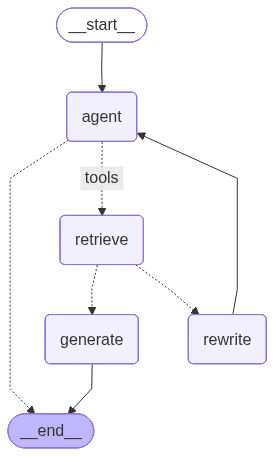

In [24]:
from langgraph.graph import END, StateGraph, START
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

# Define a new graph
workflow = StateGraph(AgentState)

# Define the nodes we will cycle between
workflow.add_node("agent", agent)  # agent
retrieve = ToolNode([retriver_tool, singer])
workflow.add_node("retrieve", retrieve)  # retrieval
workflow.add_node("rewrite", rewrite)  # Re-writing the question
workflow.add_node(
    "generate", generate
)  # Generating a response after we know the documents are relevant
# Call agent node to decide to retrieve or not
workflow.add_edge(START, "agent")

# Decide whether to retrieve
workflow.add_conditional_edges(
    "agent",
    # Assess agent decision
    tools_condition,
    {
        # Translate the condition outputs to nodes in our graph
        "tools": "retrieve",
        END: END,
    },
)

# Edges taken after the `action` node is called.
workflow.add_conditional_edges(
    "retrieve",
    # Assess agent decision
    grade_documents,
)
workflow.add_edge("generate", END)
workflow.add_edge("rewrite", "agent")

# Compile
graph = workflow.compile()
from IPython.display import Image, display
display(Image(graph.get_graph(xray=True).draw_mermaid_png()))


In [25]:
graph.invoke({"messages":"Who is Brad Pitt?"})

---CALL AGENT---
---CHECK RELEVANCE---
---DECISION: DOCS RELEVANT---
---GENERATE---


AttributeError: module 'langchainhub' has no attribute 'pull'